In [49]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [50]:
os.chdir("/Users/kaiping/Desktop/olist_project/data/interim") 
os.getcwd()

'/Users/kaiping/Desktop/olist_project/data/interim'

### 1. 讀取資料

In [51]:
file_path = Path("/Users/kaiping/Desktop/olist_project/data/interim/orders_delivered_base.csv")

orders_delivered_base = pd.read_csv(file_path)

print("原始資料筆數：", orders_delivered_base.shape[0])
print("原始欄位數：", orders_delivered_base.shape[1])
orders_delivered_base.head()

原始資料筆數： 96478
原始欄位數： 10


,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,2017-10-01
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,2018-07-01
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,2018-08-01
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,2017-11-01
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,2018-02-01


In [52]:
# =========================
# 2. 日期欄位轉型
# =========================
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders_delivered_base[col] = pd.to_datetime(orders_delivered_base[col], errors="coerce")

orders_delivered_base[date_cols].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [53]:
print("min =", orders_delivered_base["order_purchase_timestamp"].min())
print("max =", orders_delivered_base["order_purchase_timestamp"].max())

min = 2016-09-15 12:16:00
max = 2018-08-29 15:00:00


In [54]:
orders_delivered_base.isna().sum()


order_id                          0
customer_id                       0
customer_unique_id                0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
purchase_month                    0
dtype: int64

In [55]:
orders_delivered_base

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,2017-10-01
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,2018-07-01
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,2018-08-01
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,2017-11-01
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,2018-02-01
...,...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,6359f309b166b0196dbf7ad2ac62bb5a,delivered,2017-03-09 09:54:00,2017-03-09 09:54:00,2017-03-10 11:18:00,2017-03-17 15:08:00,2017-03-28,2017-03-01
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,da62f9e57a76d978d02ab5362c509660,delivered,2018-02-06 12:58:00,2018-02-06 13:10:00,2018-02-07 23:22:00,2018-02-28 17:37:00,2018-03-02,2018-02-01
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,737520a9aad80b3fbbdad19b66b37b30,delivered,2017-08-27 14:46:00,2017-08-27 15:04:00,2017-08-28 20:52:00,2017-09-21 11:24:00,2017-09-27,2017-08-01
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,5097a5312c8b157bb7be58ae360ef43c,delivered,2018-01-08 21:28:00,2018-01-08 21:36:00,2018-01-12 15:35:00,2018-01-25 23:32:00,2018-02-15,2018-01-01


### 2. order_timestamp gap=0 問題  
| 欄位                              | 意義       |
| ------------------------------- | -------- |
| `customer_unique_id`            | 顧客       |
| `prev_order_id`                 | 上一筆訂單    |
| `order_id`                      | 目前這筆訂單   |
| `prev_order_purchase_timestamp` | 上一筆訂單時間  |
| `order_purchase_timestamp`      | 目前訂單時間   |
| `gap_days`                      | 兩筆訂單間隔天數 |


In [56]:

# 依顧客與購買時間排序
orders_gap_detail = (
    orders_delivered_base
    .sort_values(
        ["customer_unique_id", "order_purchase_timestamp", "order_id"]
    )
    .copy()
)

# 取得同一顧客的上一筆訂單資訊
orders_gap_detail["prev_order_id"] = (
    orders_gap_detail
    .groupby("customer_unique_id")["order_id"]
    .shift(1)
)

orders_gap_detail["prev_order_purchase_timestamp"] = (
    orders_gap_detail
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .shift(1)
)

# 計算與上一筆訂單的間隔天數
orders_gap_detail["gap_days"] = (
    orders_gap_detail["order_purchase_timestamp"]
    - orders_gap_detail["prev_order_purchase_timestamp"]
).dt.total_seconds() / 86400

# 只保留有上一筆訂單的紀錄
order_gap_pairs = orders_gap_detail.loc[
    orders_gap_detail["prev_order_id"].notna(),
    [
        "customer_unique_id",
        "prev_order_id",
        "order_id",
        "prev_order_purchase_timestamp",
        "order_purchase_timestamp",
        "gap_days"
    ]
].copy()

order_gap_pairs.head()

,customer_unique_id,prev_order_id,order_id,prev_order_purchase_timestamp,order_purchase_timestamp,gap_days
38857,004288347e5e88a27ded2bb23747066c,a61d617fbe5bd006e40d3a0988fc844b,08204559bebd39e09ee52dcb56d8faa2,2017-07-27 14:13:00,2018-01-14 07:36:00,170.724306
87351,00a39521eb40f7012db50455bf083460,7d32c87acba91ed87ebd98310fe1c54d,cea3e6c11eb60acb9d8d4d51694832f8,2018-05-23 20:14:00,2018-06-03 10:12:00,10.581944
81665,00cc12a6d8b578b8ebd21ea4e2ae8b27,64307ceb91666760cf3ff463618302fd,d61b915b69851aec8a8865f36cfd793e,2017-03-21 19:25:00,2017-03-21 19:25:00,0.000000
47905,011575986092c30523ecb71ff10cb473,0f28d51fdd4828907bdc58b57f672e84,ed0a6265b5b0a292cd537214f401f1fc,2018-02-17 15:54:00,2018-04-18 21:58:00,60.252778
12113,011b4adcd54683b480c4d841250a987f,f05a68aaa0d8f89e758c7134d53fa22a,93b35affb86435b71ca01a6dd1eab2b1,2017-08-22 12:51:00,2018-02-15 11:40:00,176.950694


In [57]:
print(f"Total order-to-order gaps: {len(order_gap_pairs):,}")

Total order-to-order gaps: 3,120


In [58]:
gap_zero_orders = order_gap_pairs.loc[
    order_gap_pairs["gap_days"] == 0
].copy()

print(f"Gap = 0 order pairs: {len(gap_zero_orders):,}")
print(f"Gap = 0 rate: {len(gap_zero_orders) / len(order_gap_pairs):.2%}")

Gap = 0 order pairs: 707
Gap = 0 rate: 22.66%


在 order-level 的回購間隔檢查中，可以發現部分同一顧客的連續 order 之間 gap_days = 0。  
這代表若直接以 order_id 作為購買次數基礎，可能會將同一次購買中被拆分出的多筆訂單誤判為二購。

因此，本專案在後續 Retention Structure Analysis 與 First-to-Second Purchase Analysis 中，會將同一位 customer_unique_id 在相同 order_purchase_timestamp 下的多筆 order 合併為同一次 purchase event，以避免高估二購率與低估回購間隔。

In [59]:
# 資料清理

# 篩選留存分析必要欄位
retention_order_base = orders_delivered_base[
    [
        "customer_unique_id",
        "order_id",
        "order_purchase_timestamp"
    ]
].copy()
retention_order_base

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:00
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:00
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:00
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:00
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:00
...,...,...,...
96473,6359f309b166b0196dbf7ad2ac62bb5a,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:00
96474,da62f9e57a76d978d02ab5362c509660,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:00
96475,737520a9aad80b3fbbdad19b66b37b30,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:00
96476,5097a5312c8b157bb7be58ae360ef43c,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:00


In [60]:

# 同一顧客、同一購買時間，合併為同一次 purchase event
purchase_event_base = (
    retention_order_base
    .groupby(
        ["customer_unique_id", "order_purchase_timestamp"],
        as_index=False
    )
    .agg(
        order_count=("order_id", "nunique"),
        order_ids=("order_id", lambda x: ",".join(x.astype(str)))
    )
    .sort_values(["customer_unique_id", "order_purchase_timestamp"])
    .reset_index(drop=True)
)

purchase_event_base

,customer_unique_id,order_purchase_timestamp,order_count,order_ids
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,1,e22acc9c116caa3f2b7121bbb380d08e
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,1,3594e05a005ac4d06a72673270ef9ec9
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,1,b33ec3b699337181488304f362a6b734
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,1,41272756ecddd9a9ed0180413cc22fb6
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,1,d957021f1127559cd947b62533f484f7
...,...,...,...,...
95766,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:00,1,725cf8e9c24e679a8a5a32cb92c9ce1e
95767,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:00,1,c71b9252fd7b3b263aaa4cb09319a323
95768,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:00,1,fdc45e6c7555e6cb3cc0daca2557dbe1
95769,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:00,1,94d3ee0bc2a0af9d4fa47a4d63616e8d


### 3. 回購次數分析

In [61]:
# 計算每位顧客購買次數
customer_purchase_freq = (
    purchase_event_base
    .groupby("customer_unique_id", as_index=False)
    .agg(
        purchase_event_count=("order_purchase_timestamp", "count")
    )
)

customer_purchase_freq.head(5)

,customer_unique_id,purchase_event_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [62]:
# 購買次數分佈
purchase_count_dist = (
    customer_purchase_freq
    .groupby("purchase_event_count", as_index=False)
    .agg(
        customer_count=("customer_unique_id", "count")
    )
    .sort_values("purchase_event_count")
    .reset_index(drop=True)
)

# 單一購買次數占比
purchase_count_dist["customer_pct"] = (
    purchase_count_dist["customer_count"] 
    / purchase_count_dist["customer_count"].sum()
)

# 累積人數
purchase_count_dist["cum_customer_count"] = (
    purchase_count_dist["customer_count"].cumsum()
)

# 累積比例
purchase_count_dist["cum_rate"] = (
    purchase_count_dist["cum_customer_count"]
    / purchase_count_dist["customer_count"].sum()
)

# 格式整理
purchase_count_dist["customer_pct"] = purchase_count_dist["customer_pct"].round(4)
purchase_count_dist["cum_rate"] = purchase_count_dist["cum_rate"].round(4)

purchase_count_dist

,purchase_event_count,customer_count,customer_pct,cum_customer_count,cum_rate
0,1,91189,0.9768,91189,0.9768
1,2,2000,0.0214,93189,0.9982
2,3,131,0.0014,93320,0.9996
3,4,22,0.0002,93342,0.9998
4,5,8,0.0001,93350,0.9999
5,6,3,0.0000,93353,0.9999
6,7,4,0.0000,93357,1.0000
7,15,1,0.0000,93358,1.0000


In [63]:
# 計算一次性顧客和回購顧客（購買次數超過兩次) 比例
total_customers = customer_purchase_freq["customer_unique_id"].nunique()

one_time_customers = (
    customer_purchase_freq["purchase_event_count"].eq(1).sum()
)

repeat_customers = (
    customer_purchase_freq["purchase_event_count"].ge(2).sum()
)

print(f"Total customers: {total_customers:,}")
print(f"One-time customers: {one_time_customers:,} ({one_time_customers / total_customers:.2%})")
print(f"Repeat customers: {repeat_customers:,} ({repeat_customers / total_customers:.2%})")

Total customers: 93,358
One-time customers: 91,189 (97.68%)
Repeat customers: 2,169 (2.32%)


### 4.全體訂單回購間隔分析

In [64]:
# 依據顧客排序好後再根據每個顧客的購買時間排序
purchase_event_base = purchase_event_base.sort_values(
    ["customer_unique_id", "order_purchase_timestamp"]
).reset_index(drop=True)

purchase_event_base["purchase_event_rank"] = (
    purchase_event_base
    .groupby("customer_unique_id")
    .cumcount() + 1
)
purchase_event_base

,customer_unique_id,order_purchase_timestamp,order_count,order_ids,purchase_event_rank
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,1,e22acc9c116caa3f2b7121bbb380d08e,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,1,3594e05a005ac4d06a72673270ef9ec9,1
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,1,b33ec3b699337181488304f362a6b734,1
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,1,41272756ecddd9a9ed0180413cc22fb6,1
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,1,d957021f1127559cd947b62533f484f7,1
...,...,...,...,...,...
95766,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:00,1,725cf8e9c24e679a8a5a32cb92c9ce1e,1
95767,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:00,1,c71b9252fd7b3b263aaa4cb09319a323,1
95768,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:00,1,fdc45e6c7555e6cb3cc0daca2557dbe1,1
95769,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:00,1,94d3ee0bc2a0af9d4fa47a4d63616e8d,1


In [65]:
# 計算所有 purchase event 的回購間隔
# 第1次 → 第2次
# 第2次 → 第3次
# 第3次 → 第4次
# ...


purchase_event_base["prev_event_ts"] = (
    purchase_event_base
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .shift(1)
)

purchase_event_base["prev_event_rank"] = (
    purchase_event_base
    .groupby("customer_unique_id")["purchase_event_rank"]
    .shift(1)
)

purchase_event_base["gap_days"] = (
    purchase_event_base["order_purchase_timestamp"]
    - purchase_event_base["prev_event_ts"]
).dt.total_seconds() / 86400

# 只保留有上一筆購買事件的紀錄
repurchase_gap_all = purchase_event_base.loc[
    purchase_event_base["prev_event_ts"].notna(),
    [
        "customer_unique_id",
        "prev_event_rank",
        "purchase_event_rank",
        "prev_event_ts",
        "order_purchase_timestamp",
        "gap_days"
    ]
].copy()

repurchase_gap_all

,customer_unique_id,prev_event_rank,purchase_event_rank,prev_event_ts,order_purchase_timestamp,gap_days
105,004288347e5e88a27ded2bb23747066c,1.0,2,2017-07-27 14:13:00,2018-01-14 07:36:00,170.724306
245,00a39521eb40f7012db50455bf083460,1.0,2,2018-05-23 20:14:00,2018-06-03 10:12:00,10.581944
407,011575986092c30523ecb71ff10cb473,1.0,2,2018-02-17 15:54:00,2018-04-18 21:58:00,60.252778
423,011b4adcd54683b480c4d841250a987f,1.0,2,2017-08-22 12:51:00,2018-02-15 11:40:00,176.950694
433,012452d40dafae4df401bced74cdb490,1.0,2,2017-06-18 22:46:00,2018-05-14 12:12:00,329.559722
...,...,...,...,...,...,...
95332,fed519569d16e690df6f89cb99d4e682,1.0,2,2017-12-20 19:10:00,2018-03-18 21:51:00,88.111806
95401,ff03923ad1eb9e32304deb7f9b2a45c9,1.0,2,2018-04-23 21:49:00,2018-05-26 11:51:00,32.584722
95598,ff8892f7c26aa0446da53d01b18df463,1.0,2,2017-05-24 16:09:00,2017-11-26 23:25:00,186.302778
95617,ff922bdd6bafcdf99cb90d7f39cea5b3,1.0,2,2017-02-22 12:26:00,2017-08-23 13:15:00,182.034028


In [66]:
# 檢查是否有gap=0
gap_zero_1to2 = repurchase_gap_all.loc[
    repurchase_gap_all["gap_days"] == 0
]

print(f"First-to-second gap = 0 records: {len(gap_zero_1to2):,}")

First-to-second gap = 0 records: 0


In [67]:
# 購買間隔分佈
gap_desc = repurchase_gap_all["gap_days"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

print(gap_desc)

count    2413.000000
mean      102.340994
std       111.860086
min         0.000694
25%        14.863194
50%        58.986806
75%       159.643750
90%       270.503333
95%       337.128056
99%       455.678972
max       608.979167
Name: gap_days, dtype: float64


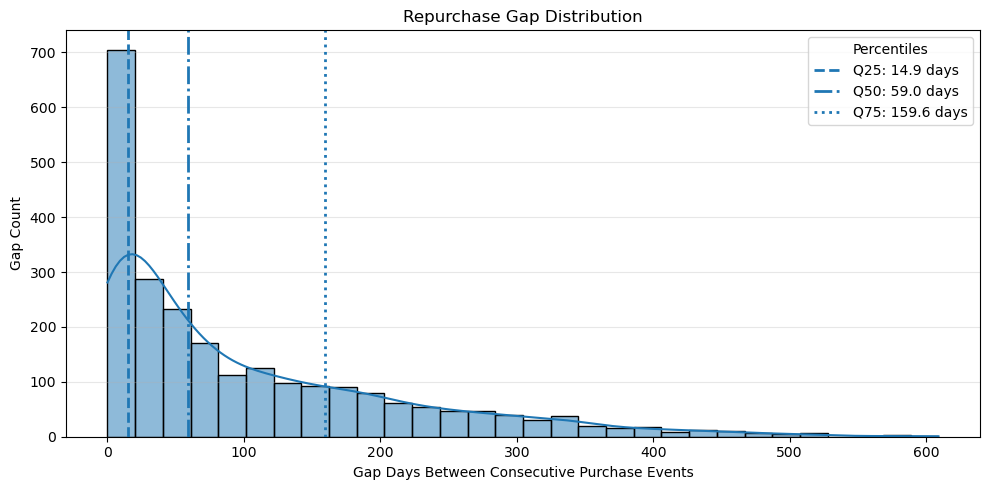

In [68]:
# 取出 gap 資料
gap_data = repurchase_gap_all["gap_days"].dropna()
gap_data = gap_data[gap_data >= 0]

# 計算分位數
q25 = gap_data.quantile(0.25)
q50 = gap_data.quantile(0.50)
q75 = gap_data.quantile(0.75)

plt.figure(figsize=(10, 5))

sns.histplot(
    gap_data,
    bins=30,
    kde=True
)

# 25分位數
plt.axvline(
    q25,
    linestyle="--",
    linewidth=2,
    label=f"Q25: {q25:.1f} days"
)

# 50分位數 / 中位數
plt.axvline(
    q50,
    linestyle="-.",
    linewidth=2,
    label=f"Q50: {q50:.1f} days"
)

# 75分位數
plt.axvline(
    q75,
    linestyle=":",
    linewidth=2,
    label=f"Q75: {q75:.1f} days"
)

plt.title("Repurchase Gap Distribution")
plt.xlabel("Gap Days Between Consecutive Purchase Events")
plt.ylabel("Gap Count")

plt.legend(title="Percentiles")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 5. 首購二購間隔分析

In [69]:
# 確保 purchase_event_base 使用完整 delivered 資料，不要先截斷尾巴 90 天
print("purchase_event_base min:", purchase_event_base["order_purchase_timestamp"].min())
print("purchase_event_base max:", purchase_event_base["order_purchase_timestamp"].max())
print("purchase_event_base rows:", len(purchase_event_base))

# 依顧客與購買時間排序
purchase_event_base = (
    purchase_event_base
    .sort_values(["customer_unique_id", "order_purchase_timestamp"])
    .copy()
)

# 建立購買事件順序
purchase_event_base["purchase_event_rank"] = (
    purchase_event_base
    .groupby("customer_unique_id")
    .cumcount() + 1
)

purchase_event_base.head()

purchase_event_base min: 2016-09-15 12:16:00
purchase_event_base max: 2018-08-29 15:00:00
purchase_event_base rows: 95771


,customer_unique_id,order_purchase_timestamp,order_count,order_ids,purchase_event_rank,prev_event_ts,prev_event_rank,gap_days
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,1,e22acc9c116caa3f2b7121bbb380d08e,1,NaT,NaN,NaN
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,1,3594e05a005ac4d06a72673270ef9ec9,1,NaT,NaN,NaN
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,1,b33ec3b699337181488304f362a6b734,1,NaT,NaN,NaN
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,1,41272756ecddd9a9ed0180413cc22fb6,1,NaT,NaN,NaN
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,1,d957021f1127559cd947b62533f484f7,1,NaT,NaN,NaN


In [70]:
# 取出首購事件

first_purchase = (
    purchase_event_base
    .loc[purchase_event_base["purchase_event_rank"] == 1,
         [
             "customer_unique_id",
             "order_purchase_timestamp",
             "order_count",
             "order_ids"
         ]]
    .rename(columns={
        "order_purchase_timestamp": "first_purchase_ts",
        "order_count": "first_order_count",
        "order_ids": "first_order_ids"
    })
    .copy()
)

print("First purchase customers:", first_purchase["customer_unique_id"].nunique())

first_purchase.head()

First purchase customers: 93358


,customer_unique_id,first_purchase_ts,first_order_count,first_order_ids
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,1,e22acc9c116caa3f2b7121bbb380d08e
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,1,3594e05a005ac4d06a72673270ef9ec9
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,1,b33ec3b699337181488304f362a6b734
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,1,41272756ecddd9a9ed0180413cc22fb6
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,1,d957021f1127559cd947b62533f484f7


In [71]:
# 取出二購事件
second_purchase = (
    purchase_event_base
    .loc[purchase_event_base["purchase_event_rank"] == 2,
         [
             "customer_unique_id",
             "order_purchase_timestamp",
             "order_count",
             "order_ids"
         ]]
    .rename(columns={
        "order_purchase_timestamp": "second_purchase_ts",
        "order_count": "second_order_count",
        "order_ids": "second_order_ids"
    })
    .copy()
)

print("Second purchase customers:", second_purchase["customer_unique_id"].nunique())

second_purchase.head()

Second purchase customers: 2169


,customer_unique_id,second_purchase_ts,second_order_count,second_order_ids
105,004288347e5e88a27ded2bb23747066c,2018-01-14 07:36:00,1,08204559bebd39e09ee52dcb56d8faa2
245,00a39521eb40f7012db50455bf083460,2018-06-03 10:12:00,1,cea3e6c11eb60acb9d8d4d51694832f8
407,011575986092c30523ecb71ff10cb473,2018-04-18 21:58:00,1,ed0a6265b5b0a292cd537214f401f1fc
423,011b4adcd54683b480c4d841250a987f,2018-02-15 11:40:00,1,93b35affb86435b71ca01a6dd1eab2b1
433,012452d40dafae4df401bced74cdb490,2018-05-14 12:12:00,1,e49d0607832db7c3b1343764225d8df6


In [72]:
# 合併首購與二購，計算 gap
first_to_second_gap = first_purchase.merge(
    second_purchase,
    on="customer_unique_id",
    how="inner",
    validate="one_to_one"
)

first_to_second_gap["gap_days"] = (
    first_to_second_gap["second_purchase_ts"]
    - first_to_second_gap["first_purchase_ts"]
).dt.total_seconds() / 86400

first_to_second_gap.head()

,customer_unique_id,first_purchase_ts,first_order_count,first_order_ids,second_purchase_ts,second_order_count,second_order_ids,gap_days
0,004288347e5e88a27ded2bb23747066c,2017-07-27 14:13:00,1,a61d617fbe5bd006e40d3a0988fc844b,2018-01-14 07:36:00,1,08204559bebd39e09ee52dcb56d8faa2,170.724306
1,00a39521eb40f7012db50455bf083460,2018-05-23 20:14:00,1,7d32c87acba91ed87ebd98310fe1c54d,2018-06-03 10:12:00,1,cea3e6c11eb60acb9d8d4d51694832f8,10.581944
2,011575986092c30523ecb71ff10cb473,2018-02-17 15:54:00,1,0f28d51fdd4828907bdc58b57f672e84,2018-04-18 21:58:00,1,ed0a6265b5b0a292cd537214f401f1fc,60.252778
3,011b4adcd54683b480c4d841250a987f,2017-08-22 12:51:00,1,f05a68aaa0d8f89e758c7134d53fa22a,2018-02-15 11:40:00,1,93b35affb86435b71ca01a6dd1eab2b1,176.950694
4,012452d40dafae4df401bced74cdb490,2017-06-18 22:46:00,1,ce2b4f2836d78829e4796213d536101e,2018-05-14 12:12:00,1,e49d0607832db7c3b1343764225d8df6,329.559722


In [73]:
print(f"First purchase customers: {first_purchase['customer_unique_id'].nunique():,}")
print(f"Second purchase customers: {second_purchase['customer_unique_id'].nunique():,}")
print(f"First-to-second gap records: {len(first_to_second_gap):,}")

First purchase customers: 93,358
Second purchase customers: 2,169
First-to-second gap records: 2,169


In [74]:
print("First purchase customers:", first_purchase["customer_unique_id"].nunique())
print("Second purchase customers:", second_purchase["customer_unique_id"].nunique())
print("First-to-second gap records:", len(first_to_second_gap))

print("Negative gap records:", (first_to_second_gap["gap_days"] < 0).sum())
print("Gap = 0 records:", (first_to_second_gap["gap_days"] == 0).sum())

first_to_second_gap["gap_days"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

First purchase customers: 93358
Second purchase customers: 2169
First-to-second gap records: 2169
Negative gap records: 0
Gap = 0 records: 0


count    2169.000000
mean      106.437371
std       114.503698
min         0.000694
25%        15.676389
50%        63.146528
75%       166.460417
90%       280.713056
95%       342.603750
99%       458.732333
max       608.979167
Name: gap_days, dtype: float64

In [75]:
data_end = purchase_event_base["order_purchase_timestamp"].max()

window_days = 90

gap_analysis_end = data_end - pd.Timedelta(days=window_days)

print("data_end:", data_end)
print("gap_analysis_end:", gap_analysis_end)

data_end: 2018-08-29 15:00:00
gap_analysis_end: 2018-05-31 15:00:00


In [76]:
# 切掉尾巴90天首購客戶
first_to_second_gap_observable = first_to_second_gap.loc[
    first_to_second_gap["first_purchase_ts"] <= gap_analysis_end
].copy()

print("Before observable filter:", len(first_to_second_gap))
print("After observable filter:", len(first_to_second_gap_observable))
print(
    "Removed tail records:",
    len(first_to_second_gap) - len(first_to_second_gap_observable)
)

Before observable filter: 2169
After observable filter: 2020
Removed tail records: 149


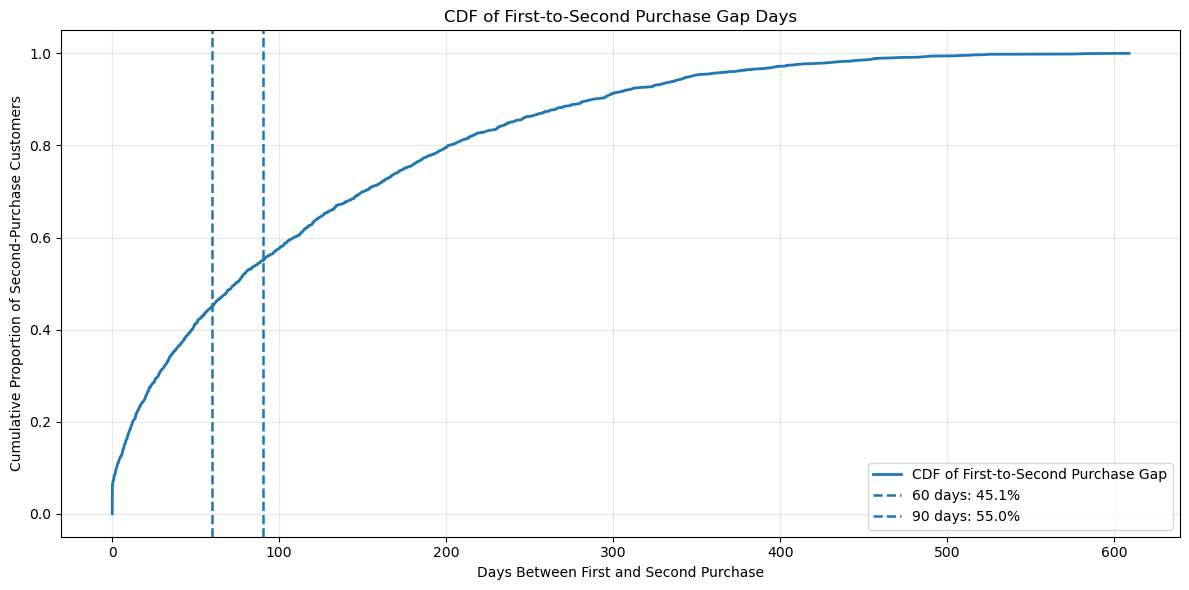

In [77]:
# 使用已經切掉尾巴 90 天的資料
plot_gap_df = first_to_second_gap_observable.copy()

# 排除異常或缺失
plot_gap_df = plot_gap_df[
    plot_gap_df["gap_days"].notna() &
    (plot_gap_df["gap_days"] >= 0)
].copy()

# CDF
gap_sorted = np.sort(plot_gap_df["gap_days"])
cum_prob = np.arange(1, len(gap_sorted) + 1) / len(gap_sorted)

plt.figure(figsize=(12, 6))

plt.plot(
    gap_sorted,
    cum_prob,
    linewidth=2,
    label="CDF of First-to-Second Purchase Gap"
)

# 標記 60 / 90 天
for d in [60, 90]:
    coverage = (plot_gap_df["gap_days"] <= d).mean()
    
    plt.axvline(
        x=d,
        linestyle="--",
        linewidth=1.8,
        label=f"{d} days: {coverage:.1%}"
    )

plt.title("CDF of First-to-Second Purchase Gap Days")
plt.xlabel("Days Between First and Second Purchase")
plt.ylabel("Cumulative Proportion of Second-Purchase Customers")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

首購至二購間隔分析顯示，在已發生二購且可完整觀察 90 天的顧客中，約 45.1% 會在首購後 60 天內完成二購，約 55.0% 會在 90 天內完成二購。這表示二購行為有明顯的早期集中現象，但仍有約 45% 的二購顧客是在 90 天後才完成回購。

因此，本專案將 90 天定義為「早期二購轉化窗口」，用於衡量首購顧客是否能在較短期間內進入第二次購買關係。
此定義適合支援首購後再行銷、優惠券觸發與會員培育策略，但不應被解讀為完整的長期回購或流失定義。

### 6. 每月首購cohort 90天內二購率分析

In [78]:

# 6.1 建立首購與二購 cohort base


# 確保 purchase_event_base 使用完整 delivered 資料
print("purchase_event_base min:", purchase_event_base["order_purchase_timestamp"].min())
print("purchase_event_base max:", purchase_event_base["order_purchase_timestamp"].max())
print("purchase_event_base rows:", len(purchase_event_base))

# 確保排序與購買事件 rank 正確
purchase_event_base = (
    purchase_event_base
    .sort_values(["customer_unique_id", "order_purchase_timestamp"])
    .copy()
)

purchase_event_base["purchase_event_rank"] = (
    purchase_event_base
    .groupby("customer_unique_id")
    .cumcount() + 1
)

# 取出首購事件
first_purchase = (
    purchase_event_base
    .loc[purchase_event_base["purchase_event_rank"] == 1,
         ["customer_unique_id", "order_purchase_timestamp"]]
    .rename(columns={"order_purchase_timestamp": "first_purchase_ts"})
    .copy()
)

# 取出二購事件
second_purchase = (
    purchase_event_base
    .loc[purchase_event_base["purchase_event_rank"] == 2,
         ["customer_unique_id", "order_purchase_timestamp"]]
    .rename(columns={"order_purchase_timestamp": "second_purchase_ts"})
    .copy()
)

# 合併成首購二購 cohort 表
first_to_second_cohort = first_purchase.merge(
    second_purchase,
    on="customer_unique_id",
    how="left",
    validate="one_to_one"
)

first_to_second_cohort["gap_days"] = (
    first_to_second_cohort["second_purchase_ts"]
    - first_to_second_cohort["first_purchase_ts"]
).dt.total_seconds() / 86400

print("First purchase customers:", len(first_purchase))
print("Second purchase customers:", len(second_purchase))
print("Cohort rows:", len(first_to_second_cohort))

first_to_second_cohort.head()

purchase_event_base min: 2016-09-15 12:16:00
purchase_event_base max: 2018-08-29 15:00:00
purchase_event_base rows: 95771
First purchase customers: 93358
Second purchase customers: 2169
Cohort rows: 93358


,customer_unique_id,first_purchase_ts,second_purchase_ts,gap_days
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,NaT,NaN
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,NaT,NaN
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,NaT,NaN
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,NaT,NaN
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,NaT,NaN


In [79]:
# 6.2 定義 90 天內是否二購


prediction_window_days = 90

first_to_second_cohort["second_purchase_within_90d"] = (
    first_to_second_cohort["gap_days"]
    .between(0, prediction_window_days, inclusive="both")
).astype(int)

first_to_second_cohort[
    ["customer_unique_id", "first_purchase_ts", "second_purchase_ts", "gap_days", "second_purchase_within_90d"]
].head()

,customer_unique_id,first_purchase_ts,second_purchase_ts,gap_days,second_purchase_within_90d
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,NaT,NaN,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,NaT,NaN,0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,NaT,NaN,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,NaT,NaN,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,NaT,NaN,0


In [80]:
# 6.3 排除無法完整觀察 90 天的首購顧客


data_end = purchase_event_base["order_purchase_timestamp"].max()
analysis_end = data_end - pd.Timedelta(days=prediction_window_days)

first_to_second_cohort["is_observable_90d"] = (
    first_to_second_cohort["first_purchase_ts"] <= analysis_end
)

print("data_end:", data_end)
print("analysis_end:", analysis_end)

print("Before censoring:", len(first_to_second_cohort))
print("Observable 90d customers:", first_to_second_cohort["is_observable_90d"].sum())
print("Tail censored customers:", (~first_to_second_cohort["is_observable_90d"]).sum())

# 正式 90 天 cohort 分析資料
first_to_second_cohort_90d = first_to_second_cohort.loc[
    first_to_second_cohort["is_observable_90d"]
].copy()

print("After censoring:", len(first_to_second_cohort_90d))

first_to_second_cohort_90d.head()

data_end: 2018-08-29 15:00:00
analysis_end: 2018-05-31 15:00:00
Before censoring: 93358
Observable 90d customers: 75320
Tail censored customers: 18038
After censoring: 75320


,customer_unique_id,first_purchase_ts,second_purchase_ts,gap_days,second_purchase_within_90d,is_observable_90d
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,NaT,NaN,0,True
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,NaT,NaN,0,True
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,NaT,NaN,0,True
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,NaT,NaN,0,True
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,NaT,NaN,0,True


In [81]:

# 6.4 Debug：檢查正式 cohort 的時間範圍

print("Full cohort max first_purchase_ts:",
      first_to_second_cohort["first_purchase_ts"].max())

print("90d observable cohort max first_purchase_ts:",
      first_to_second_cohort_90d["first_purchase_ts"].max())

print("Should be <= analysis_end:",
      first_to_second_cohort_90d["first_purchase_ts"].max() <= analysis_end)

Full cohort max first_purchase_ts: 2018-08-29 15:00:00
90d observable cohort max first_purchase_ts: 2018-05-31 14:38:00
Should be <= analysis_end: True


In [82]:
# 6.5 建立首購月份欄位


first_to_second_cohort_90d["first_purchase_month"] = (
    first_to_second_cohort_90d["first_purchase_ts"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

first_to_second_cohort_90d[
    ["customer_unique_id", "first_purchase_ts", "first_purchase_month", "second_purchase_within_90d"]
].head()

,customer_unique_id,first_purchase_ts,first_purchase_month,second_purchase_within_90d
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,2018-05-01,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,2018-05-01,0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,2017-03-01,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,2017-10-01,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,2017-11-01,0


In [83]:
# 定義90天內是否回購
prediction_window_days = 90

first_to_second_cohort["second_purchase_within_90d"] = (
    first_to_second_cohort["gap_days"].le(prediction_window_days)
).astype(int)

first_to_second_cohort

,customer_unique_id,first_purchase_ts,second_purchase_ts,gap_days,second_purchase_within_90d,is_observable_90d
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,NaT,NaN,0,True
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,NaT,NaN,0,True
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,NaT,NaN,0,True
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,NaT,NaN,0,True
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,NaT,NaN,0,True
...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:00,NaT,NaN,0,True
93354,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:00,NaT,NaN,0,True
93355,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:00,NaT,NaN,0,True
93356,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:00,NaT,NaN,0,True


In [84]:
# 建立首購月份欄位
first_to_second_cohort["first_purchase_month"] = (
    first_to_second_cohort["first_purchase_ts"]
    .dt.to_period("M")
    .dt.to_timestamp()
)
first_to_second_cohort

,customer_unique_id,first_purchase_ts,second_purchase_ts,gap_days,second_purchase_within_90d,is_observable_90d,first_purchase_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,NaT,NaN,0,True,2018-05-01
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,NaT,NaN,0,True,2018-05-01
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,NaT,NaN,0,True,2017-03-01
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,NaT,NaN,0,True,2017-10-01
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,NaT,NaN,0,True,2017-11-01
...,...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:00,NaT,NaN,0,True,2017-06-01
93354,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:00,NaT,NaN,0,True,2017-12-01
93355,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:00,NaT,NaN,0,True,2017-02-01
93356,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:00,NaT,NaN,0,True,2018-05-01


In [85]:

# 6.6 計算每月首購 cohort 90 天二購率


monthly_cohort_90d = (
    first_to_second_cohort_90d
    .groupby("first_purchase_month", as_index=False)
    .agg(
        cohort_size=("customer_unique_id", "nunique"),
        second_purchase_90d_count=("second_purchase_within_90d", "sum")
    )
    .sort_values("first_purchase_month")
    .reset_index(drop=True)
)

monthly_cohort_90d["second_purchase_90d_rate"] = (
    monthly_cohort_90d["second_purchase_90d_count"]
    / monthly_cohort_90d["cohort_size"]
)

monthly_cohort_90d["second_purchase_90d_rate_pct"] = (
    monthly_cohort_90d["second_purchase_90d_rate"] * 100
).round(2)

monthly_cohort_90d

,first_purchase_month,cohort_size,second_purchase_90d_count,second_purchase_90d_rate,second_purchase_90d_rate_pct
0,2016-09-01,1,0,0.000000,0.00
1,2016-10-01,262,2,0.007634,0.76
2,2016-12-01,1,1,1.000000,100.00
3,2017-01-01,717,13,0.018131,1.81
4,2017-02-01,1628,16,0.009828,0.98
5,2017-03-01,2503,35,0.013983,1.40
6,2017-04-01,2256,32,0.014184,1.42
7,2017-05-01,3451,61,0.017676,1.77
8,2017-06-01,3037,59,0.019427,1.94
9,2017-07-01,3752,54,0.014392,1.44


In [86]:
# 6.7 Debug：檢查 monthly cohort 最大月份


print("Monthly cohort min month:", monthly_cohort_90d["first_purchase_month"].min())
print("Monthly cohort max month:", monthly_cohort_90d["first_purchase_month"].max())

monthly_cohort_90d

Monthly cohort min month: 2016-09-01 00:00:00
Monthly cohort max month: 2018-05-01 00:00:00


,first_purchase_month,cohort_size,second_purchase_90d_count,second_purchase_90d_rate,second_purchase_90d_rate_pct
0,2016-09-01,1,0,0.000000,0.00
1,2016-10-01,262,2,0.007634,0.76
2,2016-12-01,1,1,1.000000,100.00
3,2017-01-01,717,13,0.018131,1.81
4,2017-02-01,1628,16,0.009828,0.98
5,2017-03-01,2503,35,0.013983,1.40
6,2017-04-01,2256,32,0.014184,1.42
7,2017-05-01,3451,61,0.017676,1.77
8,2017-06-01,3037,59,0.019427,1.94
9,2017-07-01,3752,54,0.014392,1.44


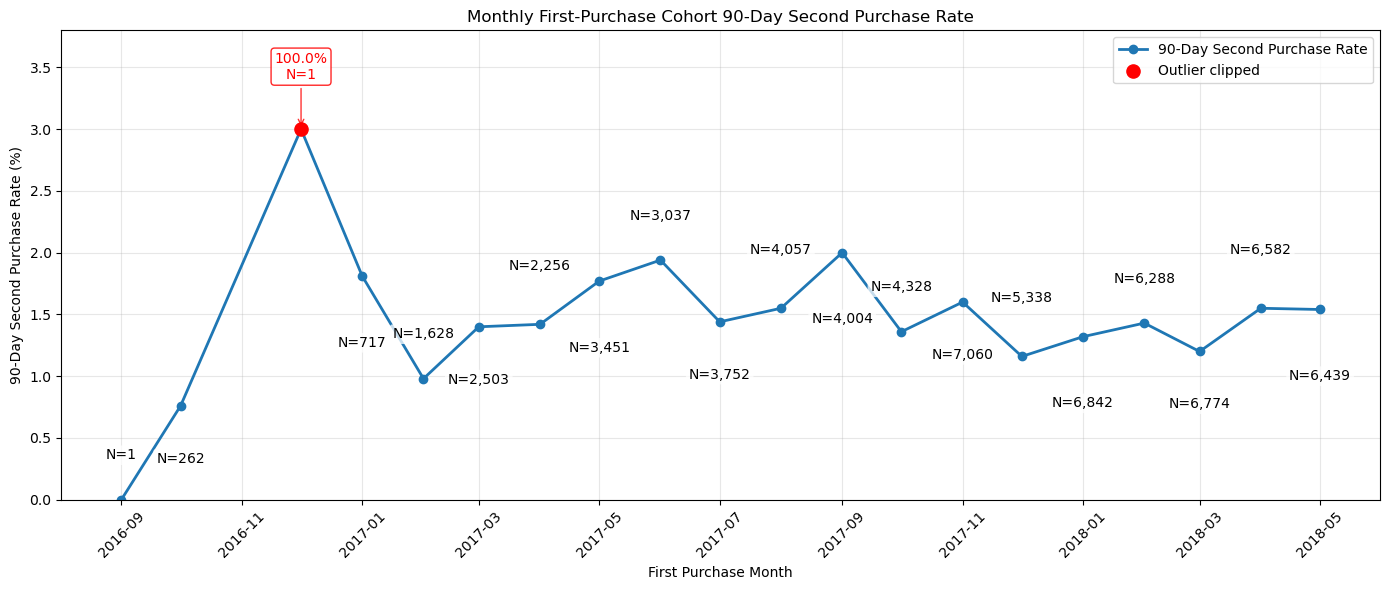

In [87]:
import matplotlib.dates as mdates

# 複製資料，避免直接修改原始 monthly_cohort_90d
plot_df = monthly_cohort_90d.copy()

# 將首購月份轉成 datetime，方便 x 軸以月份格式呈現
plot_df["first_purchase_month"] = pd.to_datetime(
    plot_df["first_purchase_month"]
)

# 重設 index，確保後續標註位置可穩定交錯排列
plot_df = plot_df.reset_index(drop=True)

# 設定 y 軸上限，讓主要二購率區間 0%~3% 更容易觀察
# 若有極端值，例如早期 cohort 因樣本數太小導致 100%，會被裁切顯示
y_cap = 3.0

# 判斷哪些 cohort 的二購率超過 y 軸上限
plot_df["is_outlier_rate"] = (
    plot_df["second_purchase_90d_rate_pct"] > y_cap
)

# 為了視覺化，將超過 y_cap 的點壓在 y_cap 位置顯示
# 原始數值仍保留在 second_purchase_90d_rate_pct 欄位中
plot_df["rate_for_plot"] = np.where(
    plot_df["is_outlier_rate"],
    y_cap,
    plot_df["second_purchase_90d_rate_pct"]
)

plt.figure(figsize=(14, 6))

# 繪製每月首購 cohort 的 90 天二購率折線圖
plt.plot(
    plot_df["first_purchase_month"],
    plot_df["rate_for_plot"],
    marker="o",
    linewidth=2,
    label="90-Day Second Purchase Rate"
)

# 取出被裁切的極端值 cohort
outliers = plot_df.loc[plot_df["is_outlier_rate"]].copy()

# 將被裁切的極端值用紅色標示，提醒讀者該點不是實際 y 值
plt.scatter(
    outliers["first_purchase_month"],
    outliers["rate_for_plot"],
    color="red",
    s=90,
    zorder=5,
    label="Outlier clipped"
)

# 標註一般 cohort 的樣本數
# 使用上下交錯方式，降低標籤互相重疊的機率
offset_pattern = [32, -38, 42, -48]

for i, row in plot_df.iterrows():

    # 極端值另外標註，避免與一般 cohort 標註邏輯混在一起
    if row["is_outlier_rate"]:
        continue

    offset_y = offset_pattern[i % len(offset_pattern)]

    plt.annotate(
        f'N={row["cohort_size"]:,}',
        xy=(row["first_purchase_month"], row["rate_for_plot"]),
        xytext=(0, offset_y),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec="none",
            alpha=0.75
        )
    )

# 標註極端值的原始二購率與 cohort size
# 讓讀者知道紅點只是被裁切顯示，不代表真實值等於 y_cap
for _, row in outliers.iterrows():
    plt.annotate(
        f'{row["second_purchase_90d_rate_pct"]:.1f}%\nN={row["cohort_size"]:,}',
        xy=(row["first_purchase_month"], row["rate_for_plot"]),
        xytext=(0, 45),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=10,
        color="red",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="red",
            alpha=0.85
        ),
        arrowprops=dict(
            arrowstyle="->",
            color="red",
            alpha=0.8
        )
    )

plt.title("Monthly First-Purchase Cohort 90-Day Second Purchase Rate")
plt.xlabel("First Purchase Month")
plt.ylabel("90-Day Second Purchase Rate (%)")

# y 軸保留一點空間，避免標籤貼到圖表上緣
plt.ylim(0, y_cap + 0.8)

# x 軸以 YYYY-MM 顯示月份
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

排除早期樣本數過小的 cohort 後，平台每月首購 cohort 的 90 天二購率大多維持在 1%–2% 之間，整體未呈現明顯改善。

### 7. 交叉對比每月訂單趨勢確認訂單增加是否會增加留存率


In [97]:

# 7.1 建立每月平台購買事件趨勢


event_df = purchase_event_base.copy()

event_df["order_purchase_timestamp"] = pd.to_datetime(
    event_df["order_purchase_timestamp"]
)

event_df["purchase_month"] = (
    event_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_event_trend = (
    event_df
    .groupby("purchase_month", as_index=False)
    .agg(
        monthly_purchase_events=("customer_unique_id", "size")
    )
    .sort_values("purchase_month")
    .reset_index(drop=True)
)

monthly_event_trend

,purchase_month,monthly_purchase_events
0,2016-09-01,1
1,2016-10-01,264
2,2016-12-01,1
3,2017-01-01,734
4,2017-02-01,1639
5,2017-03-01,2517
6,2017-04-01,2285
7,2017-05-01,3507
8,2017-06-01,3106
9,2017-07-01,3824


In [98]:

# 7.2 合併每月交易規模與每月首購 cohort 二購率

cohort_df = monthly_cohort_90d.copy()

cohort_df["first_purchase_month"] = pd.to_datetime(
    cohort_df["first_purchase_month"]
)

compare_df = cohort_df.merge(
    monthly_event_trend,
    left_on="first_purchase_month",
    right_on="purchase_month",
    how="left"
)

compare_df = compare_df.sort_values(
    "first_purchase_month"
).reset_index(drop=True)

compare_df

,first_purchase_month,cohort_size,second_purchase_90d_count,second_purchase_90d_rate,second_purchase_90d_rate_pct,purchase_month,monthly_purchase_events
0,2016-09-01,1,0,0.000000,0.00,2016-09-01,1
1,2016-10-01,262,2,0.007634,0.76,2016-10-01,264
2,2016-12-01,1,1,1.000000,100.00,2016-12-01,1
3,2017-01-01,717,13,0.018131,1.81,2017-01-01,734
4,2017-02-01,1628,16,0.009828,0.98,2017-02-01,1639
5,2017-03-01,2503,35,0.013983,1.40,2017-03-01,2517
6,2017-04-01,2256,32,0.014184,1.42,2017-04-01,2285
7,2017-05-01,3451,61,0.017676,1.77,2017-05-01,3507
8,2017-06-01,3037,59,0.019427,1.94,2017-06-01,3106
9,2017-07-01,3752,54,0.014392,1.44,2017-07-01,3824


In [100]:

# 7.3 排除 cohort size 過小月份


min_cohort_size = 500

compare_df_clean = compare_df.loc[
    compare_df["cohort_size"] >= min_cohort_size
].copy()

compare_df_clean = compare_df_clean.sort_values(
    "first_purchase_month"
).reset_index(drop=True)

compare_df_clean[
    [
        "first_purchase_month",
        "cohort_size",
        "monthly_purchase_events",
        "second_purchase_90d_count",
        "second_purchase_90d_rate_pct"
    ]
]

,first_purchase_month,cohort_size,monthly_purchase_events,second_purchase_90d_count,second_purchase_90d_rate_pct
0,2017-01-01,717,734,13,1.81
1,2017-02-01,1628,1639,16,0.98
2,2017-03-01,2503,2517,35,1.40
3,2017-04-01,2256,2285,32,1.42
4,2017-05-01,3451,3507,61,1.77
5,2017-06-01,3037,3106,59,1.94
6,2017-07-01,3752,3824,54,1.44
7,2017-08-01,4057,4136,63,1.55
8,2017-09-01,4004,4115,80,2.00
9,2017-10-01,4328,4437,59,1.36


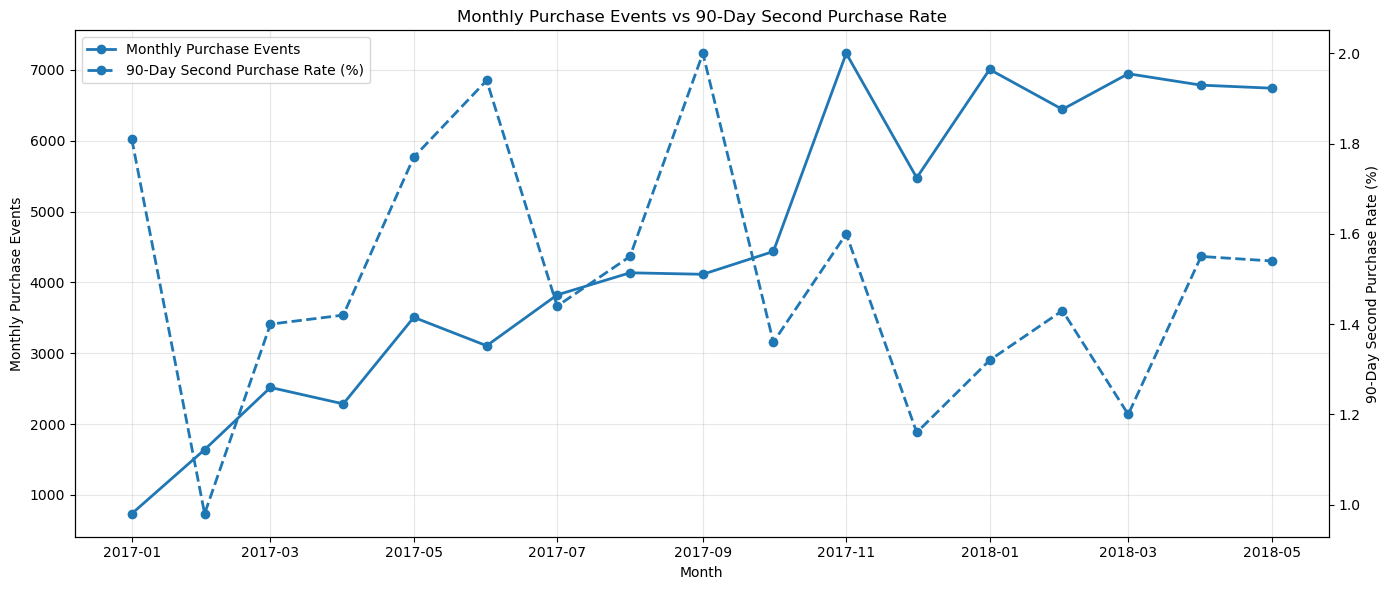

In [101]:

# 7.4 每月購買事件數 vs 90天二購率


fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    compare_df_clean["first_purchase_month"],
    compare_df_clean["monthly_purchase_events"],
    marker="o",
    linewidth=2,
    label="Monthly Purchase Events"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Monthly Purchase Events")

ax2 = ax1.twinx()

ax2.plot(
    compare_df_clean["first_purchase_month"],
    compare_df_clean["second_purchase_90d_rate_pct"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="90-Day Second Purchase Rate (%)"
)

ax2.set_ylabel("90-Day Second Purchase Rate (%)")

ax1.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.xticks(rotation=45)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

plt.title("Monthly Purchase Events vs 90-Day Second Purchase Rate")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

為確認平台交易規模成長是否同步改善留存效率，本節將每月購買事件數與每月首購 cohort 的 90 天二購率進行交叉比較。

結果顯示，2017 年後平台每月購買事件數整體呈現上升趨勢，但 90 天二購率並未隨之提升，後期高交易量月份的二購率反而偏低。這表示平台交易規模的擴張，並沒有自然轉化為更好的首購後二購效率。

因此，本專案判斷平台成長較可能來自新客流入或一次性交易增加，而非顧客留存能力改善。後續若要提升顧客長期價值，不能只依賴訂單量成長，而需要針對首購後 30–90 天的顧客設計二購轉化策略，例如回購提醒、優惠券觸發、商品推薦與會員培育。


In [104]:
# 每月首購顧客數 vs 90 天二購率分析


cohort_volume_df = monthly_cohort_90d.copy()

cohort_volume_df["first_purchase_month"] = pd.to_datetime(
    cohort_volume_df["first_purchase_month"]
)

cohort_volume_df = cohort_volume_df.sort_values(
    "first_purchase_month"
).reset_index(drop=True)

cohort_volume_df[
    [
        "first_purchase_month",
        "cohort_size",
        "second_purchase_90d_count",
        "second_purchase_90d_rate_pct"
    ]
]

,first_purchase_month,cohort_size,second_purchase_90d_count,second_purchase_90d_rate_pct
0,2016-09-01,1,0,0.00
1,2016-10-01,262,2,0.76
2,2016-12-01,1,1,100.00
3,2017-01-01,717,13,1.81
4,2017-02-01,1628,16,0.98
5,2017-03-01,2503,35,1.40
6,2017-04-01,2256,32,1.42
7,2017-05-01,3451,61,1.77
8,2017-06-01,3037,59,1.94
9,2017-07-01,3752,54,1.44


In [105]:
# 排除 cohort size 過小月份


min_cohort_size = 500

cohort_volume_clean = cohort_volume_df.loc[
    cohort_volume_df["cohort_size"] >= min_cohort_size
].copy()

cohort_volume_clean = cohort_volume_clean.sort_values(
    "first_purchase_month"
).reset_index(drop=True)

cohort_volume_clean[
    [
        "first_purchase_month",
        "cohort_size",
        "second_purchase_90d_count",
        "second_purchase_90d_rate_pct"
    ]
]

,first_purchase_month,cohort_size,second_purchase_90d_count,second_purchase_90d_rate_pct
0,2017-01-01,717,13,1.81
1,2017-02-01,1628,16,0.98
2,2017-03-01,2503,35,1.40
3,2017-04-01,2256,32,1.42
4,2017-05-01,3451,61,1.77
5,2017-06-01,3037,59,1.94
6,2017-07-01,3752,54,1.44
7,2017-08-01,4057,63,1.55
8,2017-09-01,4004,80,2.00
9,2017-10-01,4328,59,1.36


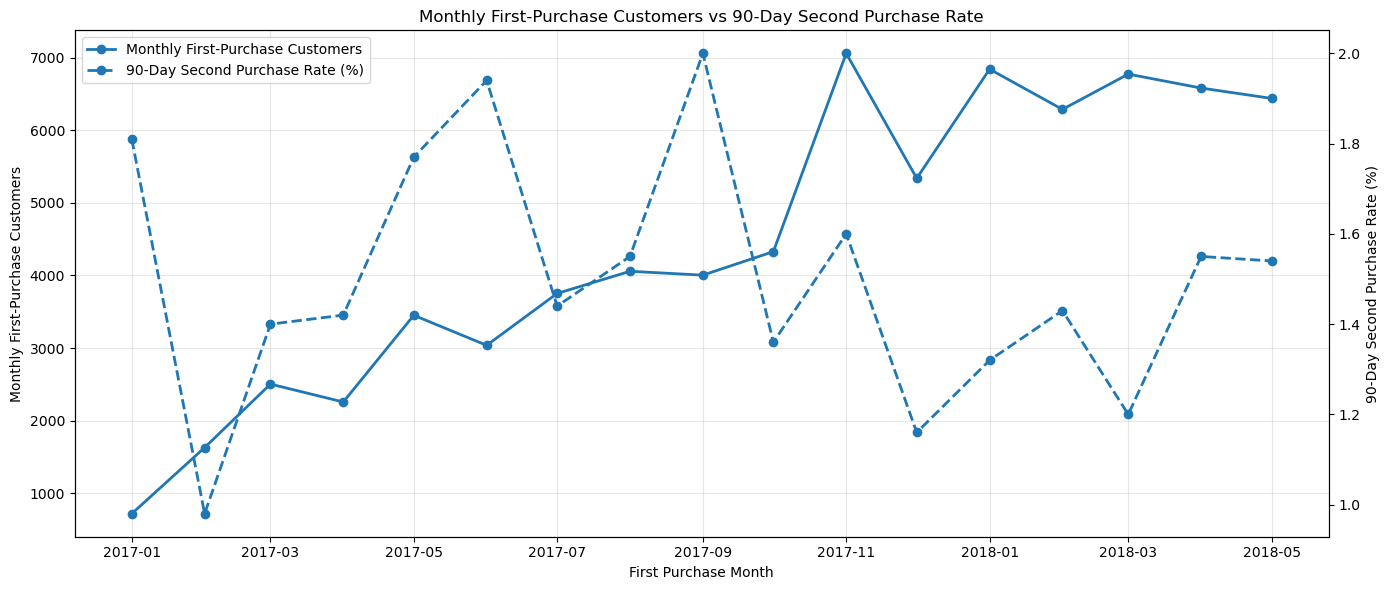

In [106]:
# 每月首購顧客數 vs 90天二購率趨勢圖

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    cohort_volume_clean["first_purchase_month"],
    cohort_volume_clean["cohort_size"],
    marker="o",
    linewidth=2,
    label="Monthly First-Purchase Customers"
)

ax1.set_xlabel("First Purchase Month")
ax1.set_ylabel("Monthly First-Purchase Customers")

ax2 = ax1.twinx()

ax2.plot(
    cohort_volume_clean["first_purchase_month"],
    cohort_volume_clean["second_purchase_90d_rate_pct"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="90-Day Second Purchase Rate (%)"
)

ax2.set_ylabel("90-Day Second Purchase Rate (%)")

ax1.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.xticks(rotation=45)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

plt.title("Monthly First-Purchase Customers vs 90-Day Second Purchase Rate")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()